In [ ]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from models.enet import enet
from models.vit import vit
from models.convnext import convnext
from utils.utils import apply_heatmap, grad_cam

dataset = "./data/AICamp-2023-Skin-Conditions_Dataset"
# dataset = "./data/Augmented_Skin_Conditions_Kaggle"
saved_model_root_path='./save_weights/'
saved_model = '0213_1129_efficientb2.pt'
saved_model_time = "_".join(saved_model.split('.')[0].split("_")[:2])
saved_model_name = "".join(saved_model.split('.')[0].split("_")[2:])

# 모델 로드
df = pd.read_csv(os.path.join(dataset, 'test.csv'))
num_classes = df['label'].nunique()

if saved_model_name.lower().__contains__('vit'):
    model, feature_extractor = vit(num_classes=num_classes)
    layer_name = model.vit.encoder.layer[-1].output
elif saved_model_name.lower().__contains__('efficient'):
    model = enet(model_name=saved_model_name, num_classes=num_classes)
    layer_name = model._blocks[-1]
elif saved_model_name.lower().__contains__('convnext'):
    model = convnext(num_classes=num_classes)
    layer_name = model.stages[-1]
else:
    raise ValueError("Unsupported model type")        

model.load_state_dict(torch.load(f'./save_weights/{saved_model}'))

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Using device: {device}')

model = model.to(device)

os.makedirs(f'img/grad_cam/{saved_model_name.split(".")[0]}', exist_ok=True)

for i in range(20):
    img_path = os.path.join(dataset, df.loc[i, 'image_path'])
    true_label = df.loc[i, 'label']
    predicted_label = df.loc[i, 'predicted_label']

    if saved_model_name.lower().__contains__('vit'):
        img_tensor = feature_extractor(images=Image.open(img_path).convert('RGB'), return_tensors="pt").pixel_values.to(device)
    else:
        img_tensor = transforms.ToTensor()(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    
    # Grad-CAM 이미지 생성
    heatmap = grad_cam(model, img_tensor, layer_name)
    original_img = cv2.imread(img_path)
    grad_cam_img = apply_heatmap(original_img, heatmap)
    grad_cam_img_uint8 = (grad_cam_img * 255).astype(np.uint8)

    # 원본 이미지와 Grad-CAM 이미지를 시각화
    fig, axes = plt.subplots(1, 2, figsize=(15, 15))
    axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original Image (Label: {true_label})')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(grad_cam_img_uint8, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM Image (Label: {predicted_label})')
    axes[1].axis('off')

    plt.show()

    # 원본 이미지와 Grad-CAM 이미지 결합
    combined_img = np.hstack((original_img, grad_cam_img))

    # 결합된 이미지 저장
    combined_output_path = f'img/grad_cam/{saved_model.split(".")[0]}/{i}.jpg'
    cv2.imwrite(combined_output_path, combined_img)

Using device: mps


/Users/jeongseung-yeon/miniconda3/envs/skin/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


# 개별 이미지 Grad_CAM 확인

Loaded pretrained weights for efficientnet-b2
Using device: mps


/Users/jeongseung-yeon/miniconda3/envs/skin/lib/python3.12/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


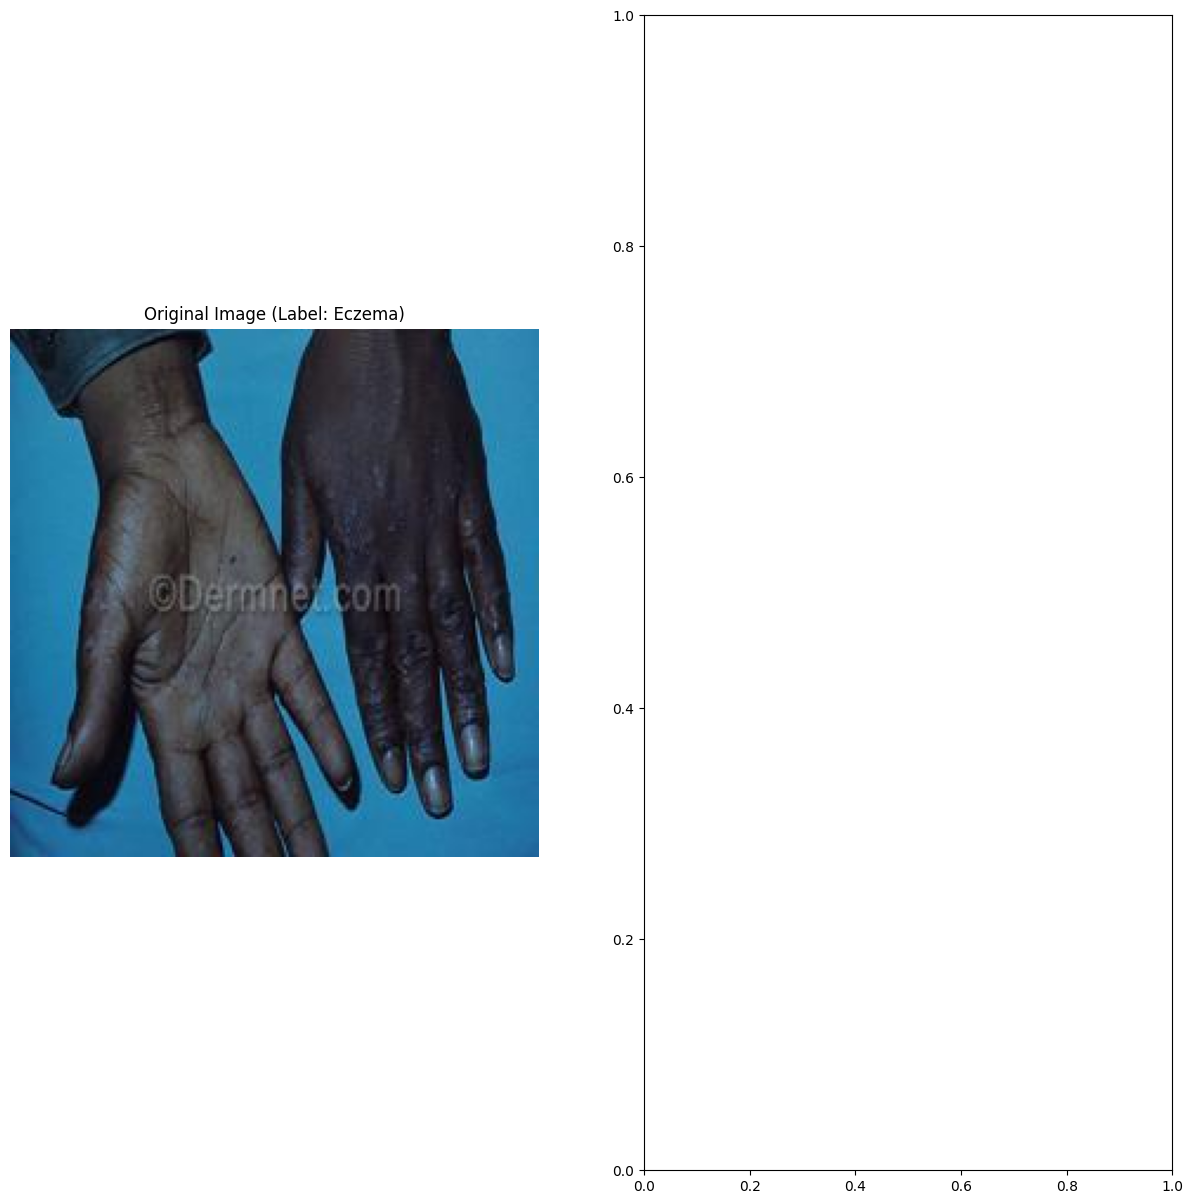

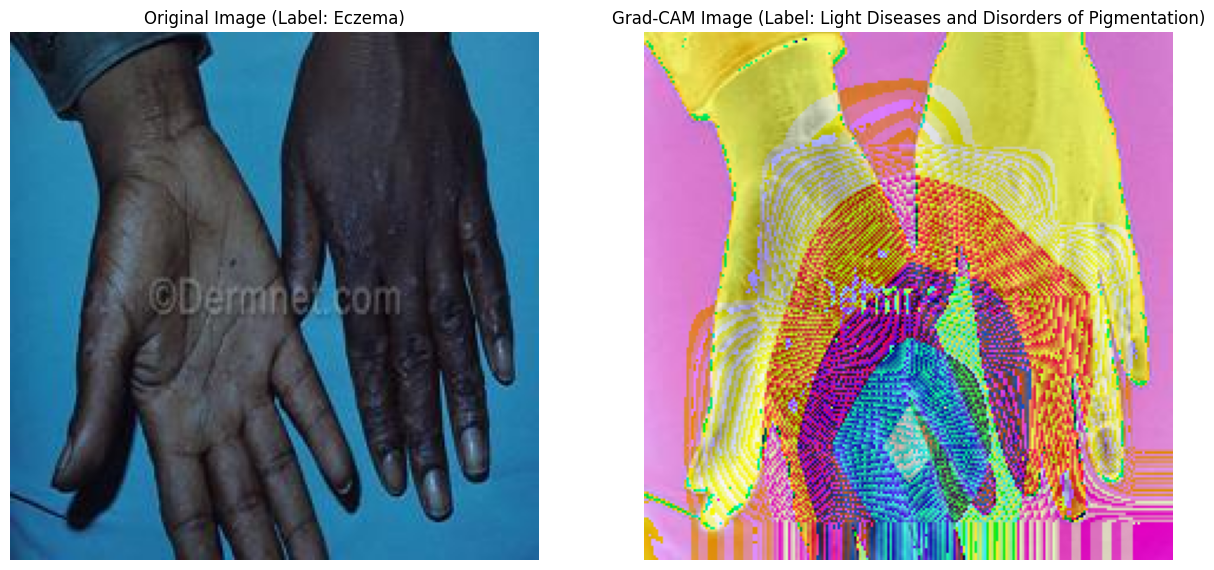

In [ ]:
import os
import torch
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from models.enet import enet
from models.vit import vit
from models.convnext import convnext
from utils.utils import apply_heatmap, grad_cam

dataset = "./data/AICamp-2023-Skin-Conditions_Dataset"
# dataset = "./data/Augmented_Skin_Conditions_Kaggle"
saved_model_root_path='./low_performance_models/'
# saved_model_root_path='./save_weights/'
saved_model = '0213_1129_efficientb2.pt'
saved_model_time = "_".join(saved_model.split('.')[0].split("_")[:2])
saved_model_name = "".join(saved_model.split('.')[0].split("_")[2:])

"Validation_Prediction_Epochs/0213_1129_efficientb2.pt/14.csv"

# results_file = "0212_1556_efficientb2_results.csv"
results_file = "14.csv"
target_img = 'train/train_660.jpg'
img_path = os.path.join(dataset, target_img)

# 모델 로드
# df = pd.read_csv(os.path.join("results", results_file), header=2)
df = pd.read_csv("Validation_Prediction_Epochs/0213_1129_efficientb2.pt/14.csv")
true_label = df[df['image']==target_img]['true_label'].values[0]
predicted_label = df[df['image']==target_img]['predicted_label'].values[0]
num_classes = df['true_label'].nunique()

if saved_model_name.lower().__contains__('vit'):
    model, feature_extractor = vit(num_classes=num_classes)
    layer_name = model.vit.encoder.layer[-1].output
elif saved_model_name.lower().__contains__('efficient'):
    model = enet(model_name=saved_model_name, num_classes=num_classes)
    layer_name = model._blocks[-1]
elif saved_model_name.lower().__contains__('convnext'):
    model = convnext(num_classes=num_classes)
    layer_name = model.stages[-1]
else:
    raise ValueError("Unsupported model type")        

model.load_state_dict(torch.load(f'./{saved_model_root_path}/{saved_model}'))

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Using device: {device}')

model = model.to(device)

if saved_model_name.lower().__contains__('vit'):
    img_tensor = feature_extractor(images=Image.open(img_path).convert('RGB'), return_tensors="pt").pixel_values.to(device)
else:
    img_tensor = transforms.ToTensor()(Image.open(img_path).convert('RGB')).to(device)

# Grad-CAM 이미지 생성
heatmap = grad_cam(model, img_tensor, layer_name)
original_img = cv2.imread(img_path)
grad_cam_img = apply_heatmap(original_img, heatmap)

# 원본 이미지와 Grad-CAM 이미지를 시각화
try: 
    fig, axes = plt.subplots(1, 2, figsize=(15, 15))
    axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original Image (Label: {true_label})')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(grad_cam_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM Image (Label: {predicted_label})')
    axes[1].axis('off')
except:
    grad_cam_img_uint8 = (grad_cam_img * 255).astype(np.uint8)
    fig, axes = plt.subplots(1, 2, figsize=(15, 15))
    axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original Image (Label: {true_label})')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(grad_cam_img_uint8, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM Image (Label: {predicted_label})')
    axes[1].axis('off')


plt.show()